Appendix A: Introduction to PyTorch (Part 1)
A.1 What is PyTorch

In [ ]:
import torch

# 打印当前安装的 PyTorch 版本号
print(torch.__version__)


In [ ]:
# 检测当前环境是否有可用的 GPU（CUDA 设备），返回 True/False
print(torch.cuda.is_available())


In [ ]:
import torch
import numpy as np

# create a 0D tensor (scalar) from a Python integer
# 创建 0 维张量（标量），形状为 ()
tensor0d = torch.tensor(1)

# create a 1D tensor (vector) from a Python list
# 创建 1 维张量（向量），形状为 (3,)
tensor1d = torch.tensor([1, 2, 3])

# create a 2D tensor from a nested Python list
# 创建 2 维张量（矩阵），形状为 (2, 2)
tensor2d = torch.tensor([[1, 2],
                         [3, 4]])

# create a 3D tensor from a nested Python list
# 创建 3 维张量，形状为 (2, 2, 2)
tensor3d_1 = torch.tensor([[[1, 2], [3, 4]],
                           [[5, 6], [7, 8]]])

# create a 3D tensor from NumPy array
# 从 NumPy 数组创建 3 维张量，形状同样为 (2, 2, 2)
ary3d = np.array([[[1, 2], [3, 4]],
                  [[5, 6], [7, 8]]])
tensor3d_2 = torch.tensor(ary3d)  # Copies NumPy array  # 复制数据，与 ary3d 不共享内存
tensor3d_3 = torch.from_numpy(ary3d)  # Shares memory with NumPy array  # 与 ary3d 共享底层内存
ary3d[0, 0, 0] = 999
print(tensor3d_2) # remains unchanged  # 因为是拷贝而来，tensor3d_2 不受 ary3d 修改影响


In [ ]:
tensor1d = torch.tensor([1, 2, 3])
# 由 Python 整数列表创建的张量，默认 dtype 为 int64
print(tensor1d.dtype)


In [ ]:
floatvec = torch.tensor([1.0, 2.0, 3.0])
# 由 Python 浮点数列表创建的张量，默认 dtype 为 float32
print(floatvec.dtype)


In [ ]:
# 使用 .to() 将 int64 张量类型转换为 float32
floatvec = tensor1d.to(torch.float32)
print(floatvec.dtype)


A.2.3 Common PyTorch tensor operations

In [ ]:
# 创建一个形状为 (2, 3) 的二维张量
tensor2d = torch.tensor([[1, 2, 3],
                         [4, 5, 6]])
tensor2d


In [ ]:
# 查看张量形状，输出 torch.Size([2, 3])
tensor2d.shape


In [ ]:
# reshape：将 (2, 3) 形状的张量重塑为 (3, 2)，元素总数需保持一致（2*3 = 3*2 = 6）
tensor2d.reshape(3, 2)

# view：与 reshape 类似，效果相同，也变为 (3, 2)（要求底层内存连续）
tensor2d.view(3, 2)

# T：转置，(2, 3) -> (3, 2)
tensor2d.T

# matmul：矩阵乘法，(2, 3) @ (3, 2) -> (2, 2)
tensor2d.matmul(tensor2d.T)

# @ 运算符等价于 matmul，结果同样是 (2, 2)
tensor2d @ tensor2d.T


A.3 Seeing models as computation graphs

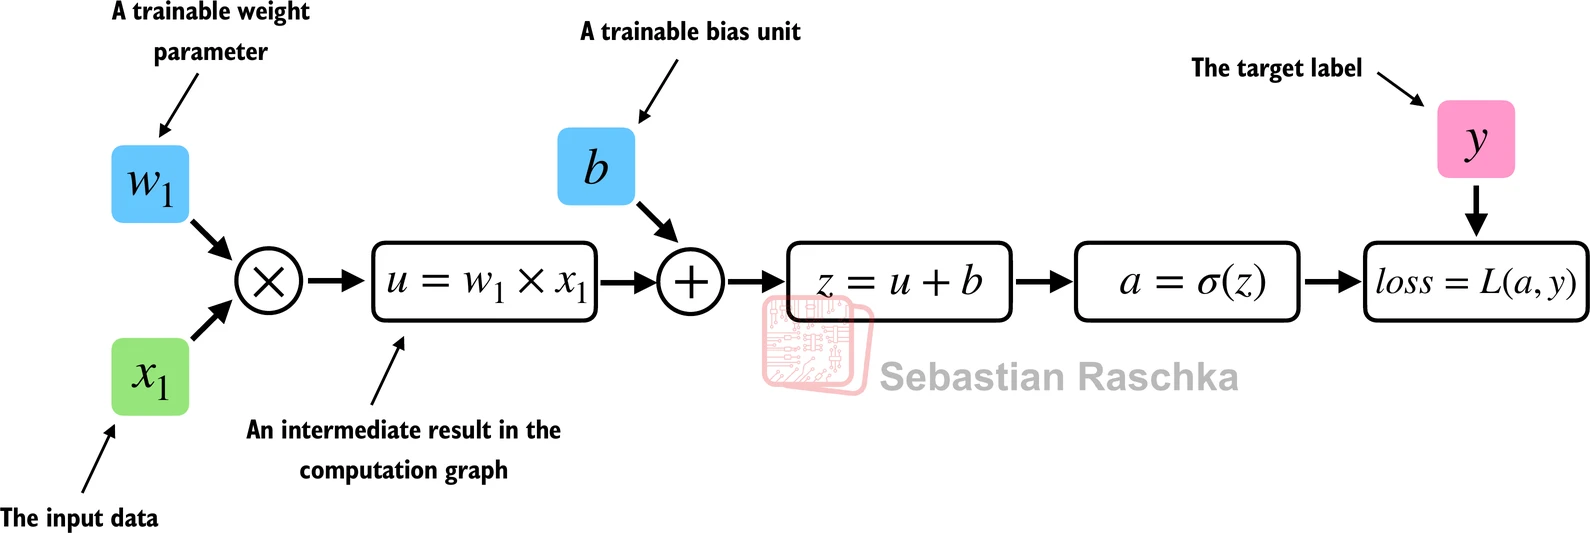

In [ ]:
import torch.nn.functional as F

# 一个最简单的逻辑回归/单神经元网络的前向计算示例
y = torch.tensor([1.0])  # true label  # 真实标签
x1 = torch.tensor([1.1]) # input feature  # 输入特征
w1 = torch.tensor([2.2]) # weight parameter  # 权重参数
b = torch.tensor([0.0])  # bias unit  # 偏置项

z = x1 * w1 + b          # net input  # 净输入（线性组合）
a = torch.sigmoid(z)     # activation & output  # sigmoid 激活，得到预测概率输出

# 计算二分类交叉熵损失（binary cross-entropy）
loss = F.binary_cross_entropy(a, y)
print(loss)


A.4 Automatic differentiation made easy
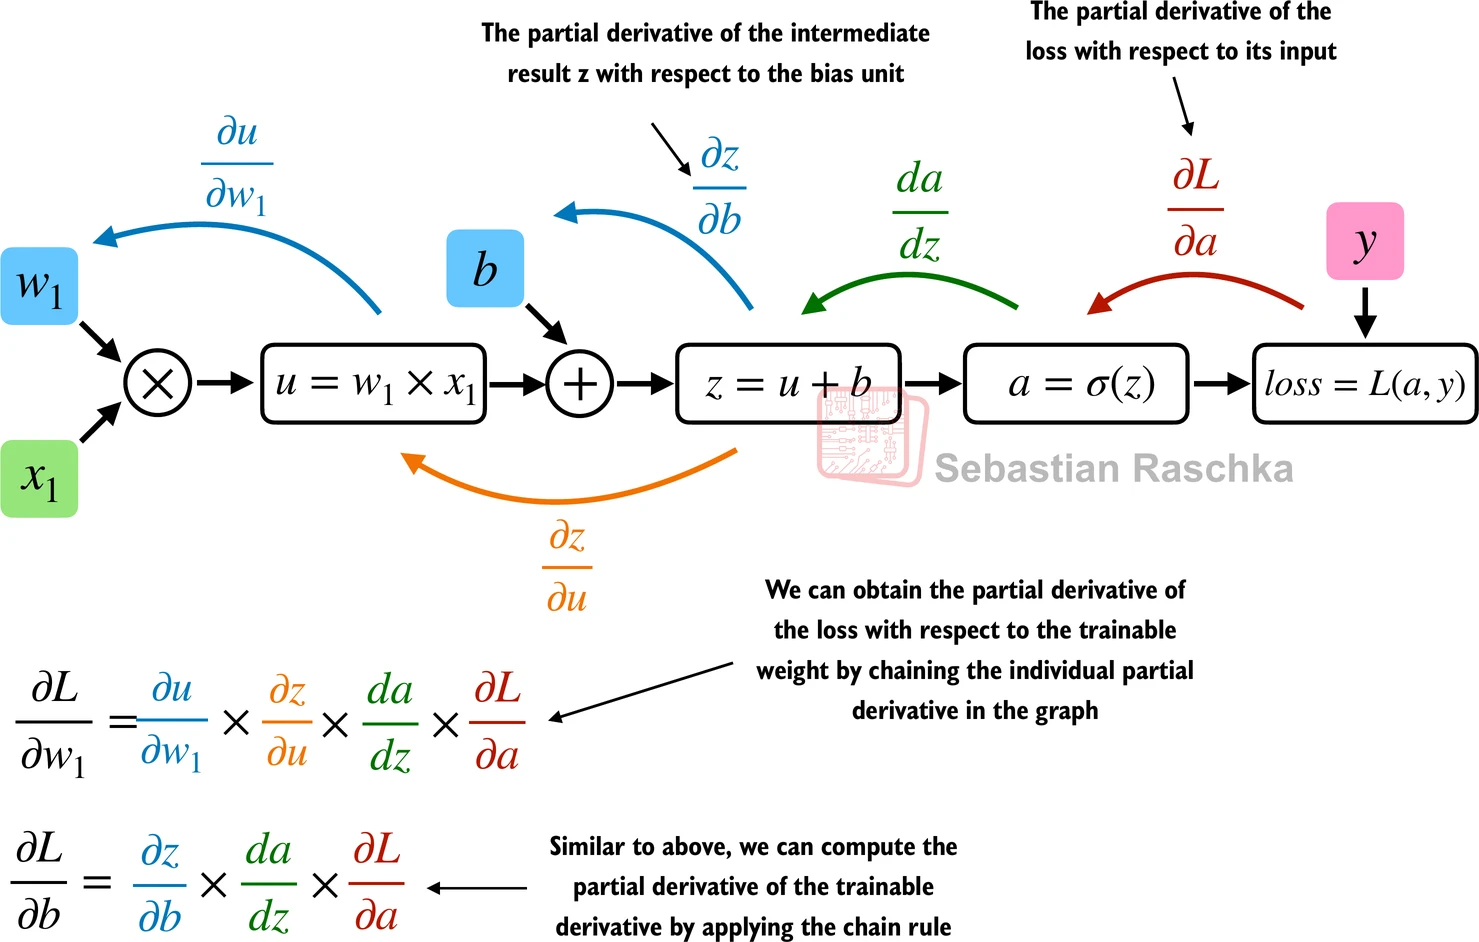

In [ ]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
# requires_grad=True 表示需要对该张量自动求导（构建计算图）
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b
a = torch.sigmoid(z)

loss = F.binary_cross_entropy(a, y)

# 使用 autograd.grad 显式求 loss 关于 w1、b 的梯度
# retain_graph=True：保留计算图，允许后续再次调用 grad/backward（否则计算图默认用后即焚）
grad_L_w1 = grad(loss, w1, retain_graph=True)
grad_L_b = grad(loss, b, retain_graph=True)

print(grad_L_w1)
print(grad_L_b)


In [ ]:
# 反向传播：自动计算 loss 对所有 requires_grad=True 张量的梯度
# 梯度会被累加到各自的 .grad 属性中（而不是像 grad() 那样返回值）
loss.backward()

print(w1.grad)
print(b.grad)


A.5 Implementing multilayer neural networks
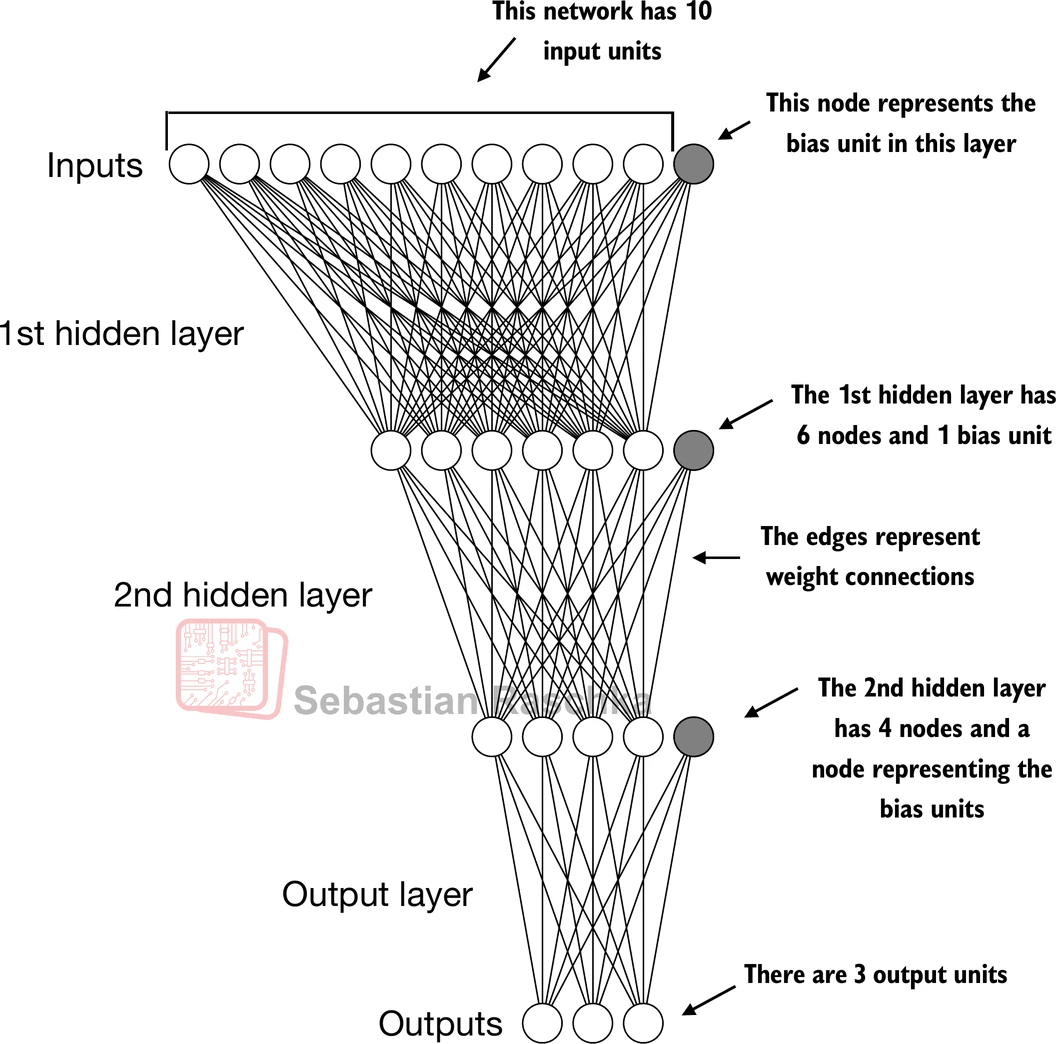

In [ ]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        # 使用 Sequential 顺序堆叠各层，构成一个简单的多层感知机（MLP）
        self.layers = torch.nn.Sequential(

            # 1st hidden layer
            # 第一隐藏层：输入维度 num_inputs -> 输出维度 30
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            # 2nd hidden layer
            # 第二隐藏层：30 -> 20
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # output layer
            # 输出层：20 -> num_outputs，不加激活函数，输出未归一化的 logits
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        # 前向传播，x 形状 (batch_size, num_inputs) -> logits 形状 (batch_size, num_outputs)
        logits = self.layers(x)
        return logits
# 实例化网络：输入维度 50，输出维度 3（例如 3 分类任务）
model = NeuralNetwork(50, 3)
print(model)


In [ ]:
# 统计模型中所有可训练参数（requires_grad=True）的元素总数
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total number of trainable model parameters:", num_params)


In [ ]:
# 查看第一层（Linear(50, 30)）的权重矩阵，形状为 (30, 50)
print(model.layers[0].weight)


In [ ]:
# 固定随机种子以保证权重初始化结果可复现
torch.manual_seed(123)

model = NeuralNetwork(50, 3)
print(model.layers[0].weight)
# 打印第一层权重矩阵形状，应为 torch.Size([30, 50])
print(model.layers[0].weight.shape)


In [ ]:
torch.manual_seed(123)

# 构造一个随机输入，形状为 (1, 50)，即 batch_size=1，特征维度 50
X = torch.rand((1, 50))
# 前向传播，输出 logits 形状为 (1, 3)
# 注意：out 会带有 grad_fn，因为默认处于训练模式（梯度追踪开启）
out = model(X)
print(out)


In [ ]:
# torch.no_grad() 上下文：关闭梯度追踪，不构建计算图
# 适用于推理阶段，可减少显存占用、加快计算速度
with torch.no_grad():
    out = model(X)
print(out)


In [ ]:
# 对 logits 沿 dim=1（类别维度）做 softmax，转换为类别概率分布，和为 1
with torch.no_grad():
    out = torch.softmax(model(X), dim=1)
print(out)


A.6 Setting up efficient data loaders
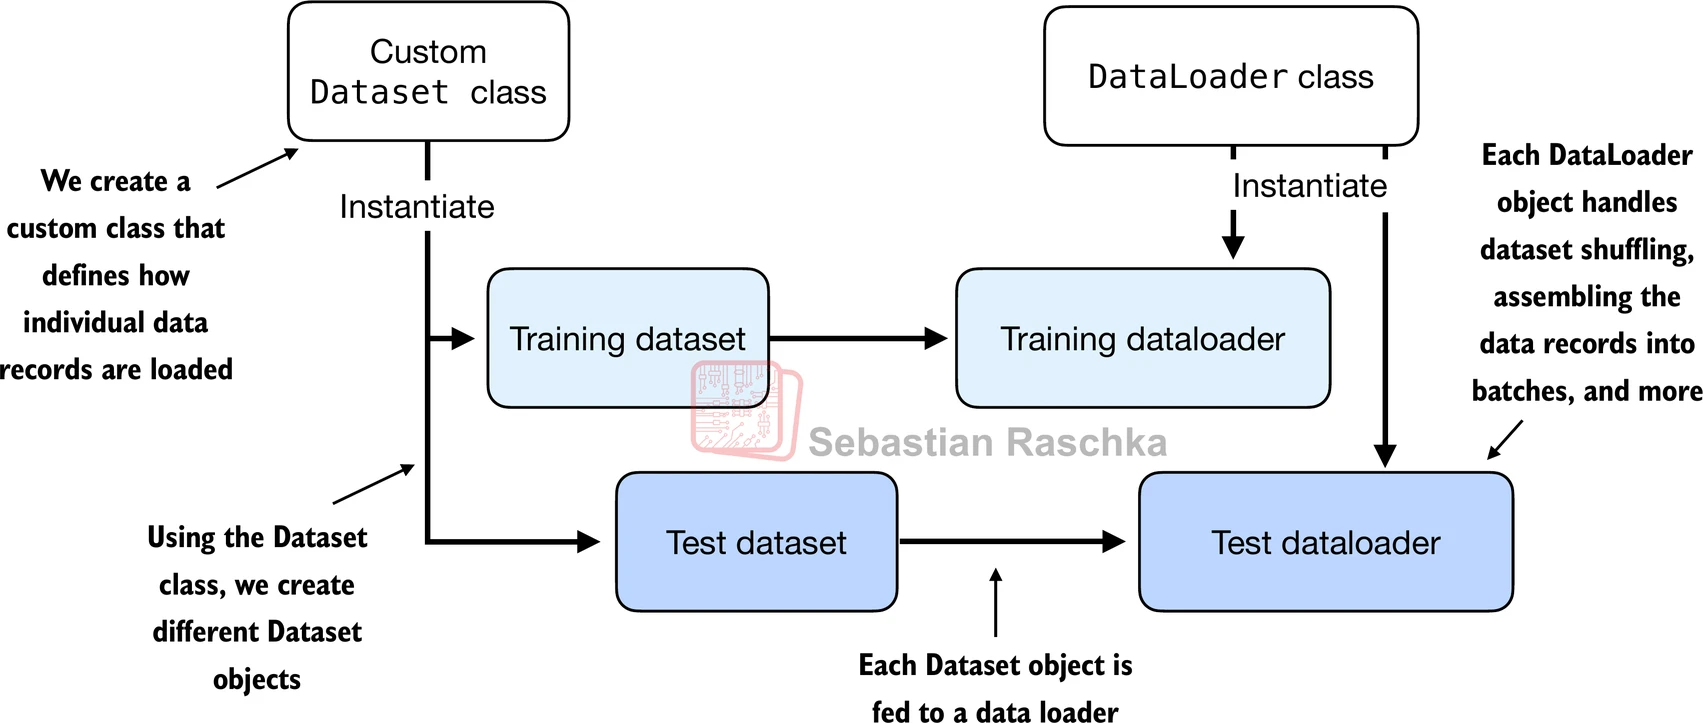

In [ ]:
# 构造一个简单的二分类玩具数据集
# 训练集：5 个样本，每个样本 2 个特征
X_train = torch.tensor([
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])

# 训练集标签：0 或 1
y_train = torch.tensor([0, 0, 0, 1, 1])
# 测试集：2 个样本
X_test = torch.tensor([
    [-0.8, 2.8],
    [2.6, -1.6],
])

y_test = torch.tensor([0, 1])


In [ ]:
from torch.utils.data import Dataset


# 自定义 Dataset 子类，需实现 __getitem__ 和 __len__
class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):
        # 根据索引返回一个 (特征, 标签) 样本对
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y

    def __len__(self):
        # 返回数据集样本总数
        return self.labels.shape[0]

train_ds = ToyDataset(X_train, y_train)
test_ds = ToyDataset(X_test, y_test)
# 训练集样本数量，应为 5
len(train_ds)


In [ ]:
from torch.utils.data import DataLoader

torch.manual_seed(123)

# DataLoader 负责按 batch_size 打包样本，并可选地打乱顺序（shuffle）
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,      # 训练集打乱顺序，有助于模型泛化
    num_workers=0
)
test_ds = ToyDataset(X_test, y_test)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,      # 测试集无需打乱
    num_workers=0
)
# 遍历训练 DataLoader，5 个样本、batch_size=2，共产生 3 个 batch（最后一个 batch 只有 1 个样本）
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)


In [ ]:
# drop_last=True：当样本数不能被 batch_size 整除时，丢弃最后一个不完整的 batch
# 5 个样本 / batch_size=2 -> 保留 2 个完整 batch，丢弃最后剩余的 1 个样本
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True
)
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)


A.7 A typical training loop


In [ ]:
import torch.nn.functional as F


torch.manual_seed(123)
# 输入 2 维特征，输出 2 分类 logits
model = NeuralNetwork(num_inputs=2, num_outputs=2)
# 使用随机梯度下降（SGD）优化器，学习率 lr=0.5
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

num_epochs = 3

# 典型的 PyTorch 训练循环：外层遍历 epoch，内层遍历 mini-batch
for epoch in range(num_epochs):

    model.train()  # 切换到训练模式（启用 Dropout/BatchNorm 等训练行为，此模型中无实际影响）
    for batch_idx, (features, labels) in enumerate(train_loader):

        # 前向传播，得到 logits
        logits = model(features)

        loss = F.cross_entropy(logits, labels) # Loss function  # 多分类交叉熵损失（内部包含 softmax）

        optimizer.zero_grad()   # 清空上一步残留的梯度
        loss.backward()         # 反向传播，计算梯度
        optimizer.step()        # 根据梯度更新模型参数

        ### LOGGING
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx+1:03d}/{len(train_loader):03d}"
              f" | Train/Val Loss: {loss:.2f}")

    model.eval()  # 切换到评估模式
    # Optional model evaluation  # 此处可选地加入验证集评估逻辑


In [ ]:
model.eval()  # 评估模式

# 关闭梯度追踪，对整个训练集做一次前向推理
with torch.no_grad():
    outputs = model(X_train)

# 输出未经 softmax 处理的原始 logits，形状为 (5, 2)
print(outputs)


In [ ]:
# 关闭科学计数法显示，便于直观查看概率值
torch.set_printoptions(sci_mode=False)
# 对 logits 做 softmax，得到每个样本属于各类别的概率
probas = torch.softmax(outputs, dim=1)
print(probas)

# argmax 沿类别维度取概率最大的类别下标，作为预测标签
predictions = torch.argmax(probas, dim=1)
print(predictions)


In [ ]:
# softmax 是单调变换，不改变大小关系，因此可以直接对 logits 取 argmax
# 得到与对 probas 取 argmax 完全相同的预测结果，省去 softmax 计算
predictions = torch.argmax(outputs, dim=1)
print(predictions)


In [ ]:
# 逐元素比较预测值与真实标签，得到布尔张量
predictions == y_train


In [ ]:
# 对布尔张量求和，得到预测正确的样本数量
torch.sum(predictions == y_train)


In [ ]:
def compute_accuracy(model, dataloader):
    # 通用的准确率计算函数：遍历整个 dataloader，统计预测正确的样本数占比

    model.eval()  # 评估模式
    correct = 0.0
    total_examples = 0

    for idx, (features, labels) in enumerate(dataloader):

        with torch.no_grad():  # 推理阶段无需梯度
            logits = model(features)

        # 取每个样本预测概率最高的类别
        predictions = torch.argmax(logits, dim=1)
        compare = labels == predictions
        correct += torch.sum(compare)          # 累加正确预测数
        total_examples += len(compare)          # 累加样本总数

    # 返回准确率（正确数 / 总数），.item() 将单元素张量转为 Python 标量
    return (correct / total_examples).item()


In [ ]:
# 在训练集上计算模型准确率
compute_accuracy(model, train_loader)


In [ ]:
# 在测试集上计算模型准确率
compute_accuracy(model, test_loader)


A.8 Saving and loading models

In [ ]:
# 保存模型参数（state_dict，即各层权重/偏置的字典），而不是保存整个模型对象
torch.save(model.state_dict(), "model.pth")
# 加载时需要先用同样的结构重新构建模型
model = NeuralNetwork(2, 2) # needs to match the original model exactly  # 必须与原模型结构完全一致
# weights_only=True：仅反序列化张量权重，不执行任意代码，加载更安全
model.load_state_dict(torch.load("model.pth", weights_only=True))


A.9 Optimizing training performance with GPUs